In [1]:
import torch
# torch.autograd.set_detect_anomaly(True)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR

from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,
    denorm,TP_TN_FP_FN,class_weighting)
from utils.preprocessing import (
    WhiteTopHat , CLAHE , normalize_xca , 
    morph_binary_mask , DoubleClahe,laplacian_pyramid_enhance,
    Meijering,BrightnessMultiplicativeNNUNet2D,ContrastAugmentationNNUNet2D)
from utils.dataset import  UnetDataset , ValidUnetDataset , make_dataloader
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from models.swin_encoder import SwinEncoder , SwinUperNet
from models.CM_UNet import CM_UNet
from utils.losses import MainLossFn
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [2]:
with open("./hyper_params/binary_args.json","r") as f:
    args = json.load(f)
    
args["class_count"] = 2 if args["just_binary_trining"] else 26
if args["just_binary_trining"]:
    class_map = {
        1:"fg"
    }
    
else:
    class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7: '7',8: '8',
        9: '9',10: '9a',11: '10',12: '10a',
        13: '11',14: '12',15: '12a',16: '13',
        17: '14',18: '14a',19: '15',20: '16',
        21: '16a',22: '16b',23: '16c',
        24: '12b',25: '14b'
    }

rare = {
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b',18: '14a',
    10: '9a',12: '10a',15: '12a',11: '10'
}

common ={
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',13: '11',14: '12',19: '15',
    20: '16',16: '13',17: '14'
}

train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# losses_keys = ["total loss","FCE loss",args["loss_tgrad_normype"]]

losses_keys = [
    "total loss",
    "binary loss",
    # "bianry cldice loss ",
    "binary dice loss",
    "binary BCE loss"
    # "binary clce loss"
    # f"{args["loss_type"]}_abs",
    # f"{args["loss_type"]}_main",
]
out_counts = args["unet_depth"] if args["dsv_bottleneck"] else args["unet_depth"] -1 
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625]

In [3]:
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
no class weights being used


In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    # A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.2),


    A.Affine( 
        scale=(0.8, 1.2), 
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30), 
        shear=(-10, 10), 
        fill=0, 
        fill_mask=0, 
        border_mode=cv2.BORDER_CONSTANT, 
        fit_output=False, 
    p=0.3),
    A.RandomGamma(
        gamma_limit=(70, 150), 
        p=0.3
    ),
    A.Compose([
        A.InvertImg(p=1.0),
        A.RandomGamma(gamma_limit=(70, 150), p=1.0),
        A.InvertImg(p=1.0),
    ], p=0.15),
    A.Downscale(
        scale_range=(0.5, 1.0),  # downsample factor
        interpolation_pair={
            "downscale": cv2.INTER_NEAREST,
            "upscale": cv2.INTER_CUBIC,  
        },
        p=0.25,  
    ),
    A.GaussianBlur(
        sigma_limit=(0.5, 1.0),
        blur_limit=0,     
        p=0.2,      
    ),
    BrightnessMultiplicativeNNUNet2D(multiplier_range=(0.70, 1.3), p=0.15),
    ContrastAugmentationNNUNet2D(contrast_range=(0.65, 1.5), p=0.15),
    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    A.Lambda(image=normalize_xca)
    # A.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225],
    #     max_pixel_value=255.0
    # )

],additional_targets={'binary_mask':'mask'})

test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    # A.Resize(*args["image_shape"]),
    A.Lambda(image=normalize_xca)
    # A.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225],
    #     max_pixel_value=255.0
    # )
],additional_targets={'binary_mask':'mask'})
# train_preprocess = [
#     # WhiteTopHat(kernel_size=(50,50)),
#     # CLAHE()
#     # DoubleClahe(kernel_size=(3,3),tile_grid=(10,10))
#     # laplacian_pyramid_enhance
#     # Meijering()
# ]
train_preprocess = None


/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:154: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:167: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [6]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"],
    resize_binary = args["resize_binary"],
    k = args["k"],
    just_binary_trining=False
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"],
    resize_binary = args["resize_binary"],
    k = args["k"],
    just_binary_trining=False
)
# print(sampler_weights)


max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

0
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

0


In [7]:
train_ds = UnetDataset(
    transform = train_transforms,
    data = train_images,
    base_size=args["image_shape"],
    crop_prob=args["crop_prob"],
    valid=False,
    out_counts = out_counts,
    binary_type= args["binary_type"]
)
valid_ds = UnetDataset(
    transform = test_transforms,
    data = valid_images,
    base_size=args["image_shape"],
    valid=True,
    out_counts = out_counts,
    binary_type= args["binary_type"]
)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

using weighted sampler here
valid with no sampler


torch.Size([10, 1, 512, 512])
torch.Size([10, 1, 512, 512])
[0 1]


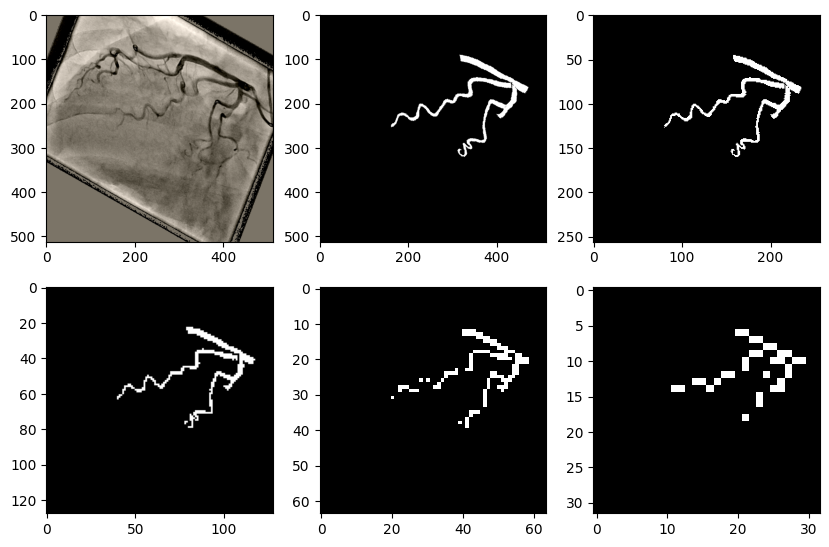

In [8]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)

for img,mask in train_loader:
    print(img.shape)
    print(mask[0].shape)
    ### binary check 
    index=0
    print(np.unique(mask[0][index].numpy()))
    ### abs check 
    img = denorm(img[index],mean=IMAGENET_MEAN,std=IMAGENET_STD)
    plt.figure(figsize=(10,10))

    plt.subplot(3,3,1)
    plt.imshow(img,cmap="gray")
    for i in range(1,out_counts+1):
        plt.subplot(3,3,i+1)
        if(args["just_binary_trining"]):
            # print(mask[i].shape)
            plt.imshow(mask[i-1][index][0].numpy(),cmap="gray")
        else:
            # colored_25 = draw_mask(image=img,mask=mask[index].numpy(),colors=colors)
            # plt.imshow(colored_25)
            pass

    # plt.subplot(2,2,3)
    # plt.imshow(common_mask[index][0].numpy(),cmap="gray")
    # plt.subplot(2,2,4)
    # plt.imshow(rare_mask[index][0].numpy(),cmap="gray")
    break


In [9]:
# plot_some_images(train_images, train_transforms, mean=IMAGENET_MEAN,std=IMAGENET_STD,image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [10]:
class UnetP(torch.nn.Module):
    def __init__(self):
        super(UnetP,self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name="resnet50",  
            encoder_weights="imagenet",  
            in_channels=3,               
            classes=2
        )
    def forward(self,x):
        return [self.model(x)]

In [11]:
# model = SwinEncoder(args).to(args["device"])
# model = UnetP().to(args["device"])
model = nnUnet(args).to(args["device"])
loss_fn = MainLossFn(args)

optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
# optimizer = torch.optim.AdamW(
#     model.parameters(), 
#     lr=args["lr"], 
#     betas=(0.9, 0.999), 
#     eps=1e-08, 
#     weight_decay=args["weight_decay"]
# )
if(args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
else:
    lr_sch = None

recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map,class_count=args["class_count"])

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)
# ls = torch.rand(2,3,448,448).to("cuda")

number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  2
loss is set to tversky


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.0005
train ==> epcoh (0)
total loss : 1.4030349993705749 - binary loss : 1.4030349993705749 - binary dice loss : 1.1588903695344925
binary BCE loss : 0.24414463259279728 - 
train avg metrics for epoch 0 :
avg dice : 0.47547075152397156 - avg precision : 0.3294231593608856 - avg recall : 0.8541542887687683
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.0206914693117142 - binary loss : 1.0206914693117142 - binary dice loss : 0.8141219764947891
binary BCE loss : 0.20656949877738953 - 
valid avg metrics for epoch 0 :
avg dice : 0.6630652546882629 - avg precision : 0.5457818508148193 - avg recall : 0.8445513248443604
------------------------------------------------------------
New Best! : dice = 0.6630652546882629


  0%|          | 0/100 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(0.3768, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.8734, device='cuda:0')
----------------------

current lr : 0.0005
train ==> epcoh (7)
total loss : 0.3627877175807953 - binary loss : 0.3627877175807953 - binary dice loss : 0.1961108586192131
binary BCE loss : 0.1666768578439951 - 
train avg metrics for epoch 7 :
avg dice : 0.7796229720115662 - avg precision : 0.726131796836853 - avg recall : 0.8416218757629395
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (7)
total loss : 0.3758285291492939 - binary loss : 0.3758285291492939 - binary dice loss : 0.17286567389965057
binary BCE loss : 0.20296285562217237 - 
valid avg metrics for epoch 7 :
avg dice : 0.7771962881088257 - avg precision : 0.746785044670105 - avg recall : 0.8101894855499268
------------------------------------------------------------
New Best! : dice = 0.7771962881088257


  0%|          | 0/100 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.3654, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7645, device='cuda:0')
----------------------

--- Total Norm ---
tensor(0.3855, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.8323, device='cuda:0')
----------------------

--- Total Norm ---
tensor(0.3265, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.0204, device='cuda:0')
----------------------

current lr : 0.0005
train ==> epcoh (8)
total loss : 0.34682704478502274 - binary loss : 0.34682704478502274 - binary dice loss : 0.18715666562318803
binary BCE loss : 0.15967037945985793 - 
train avg metrics for epoch 8 :
avg dice : 0.7833034992218018 - avg precision : 0.7285259962081909 - avg recall : 0.8469881415367126
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (8)
total loss : 0.3790851004421711 - binary loss : 0.3790851004421711 - binary dice loss : 0.18845095932483674
binary BCE loss : 0.19063414372503756 - 
valid avg metrics for epoch 8 :
avg dice : 0.77439105

  0%|          | 0/100 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.3384, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9367, device='cuda:0')
----------------------

--- Total Norm ---
tensor(0.2933, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.1081, device='cuda:0')
----------------------

current lr : 0.0005
train ==> epcoh (9)
total loss : 0.33647237107157707 - binary loss : 0.33647237107157707 - binary dice loss : 0.17877984456717969
binary BCE loss : 0.15769252710044385 - 
train avg metrics for epoch 9 :
avg dice : 0.788157045841217 - avg precision : 0.7352480292320251 - avg recall : 0.8492711782455444
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (9)
total loss : 0.36277972012758253 - binary loss : 0.36277972012758253 - binary dice loss : 0.16953987553715705
binary BCE loss : 0.19323985017836093 - 
valid avg metrics for epoch 9 :
avg dice : 0.7822220921516418 - avg precision : 0.7518869638442993 - avg recall : 0.8151078820228577
fg => dice : 0.7822220921516418 p : 0.751886963844

Save Model
Saving Memory
Saving All Plots
Saving Examples
Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 3176.41it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  4.81it/s]

processing ./temp_script.py


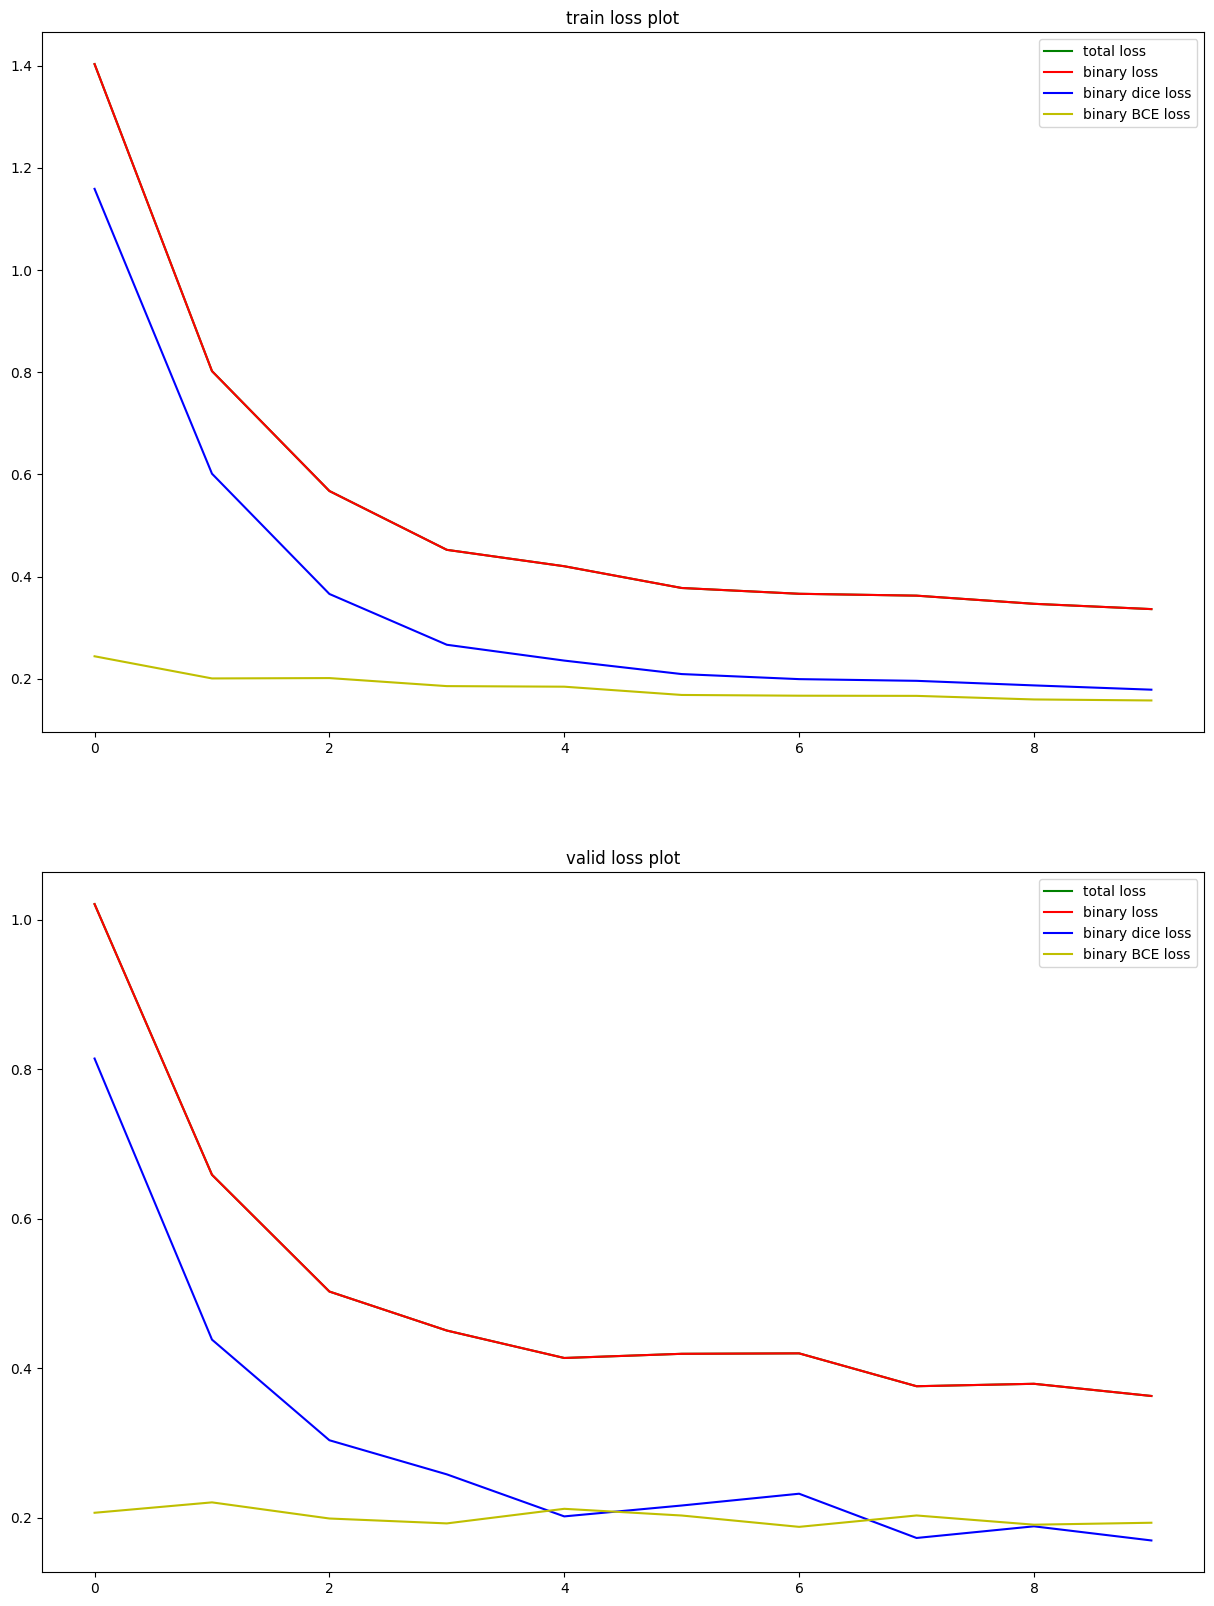

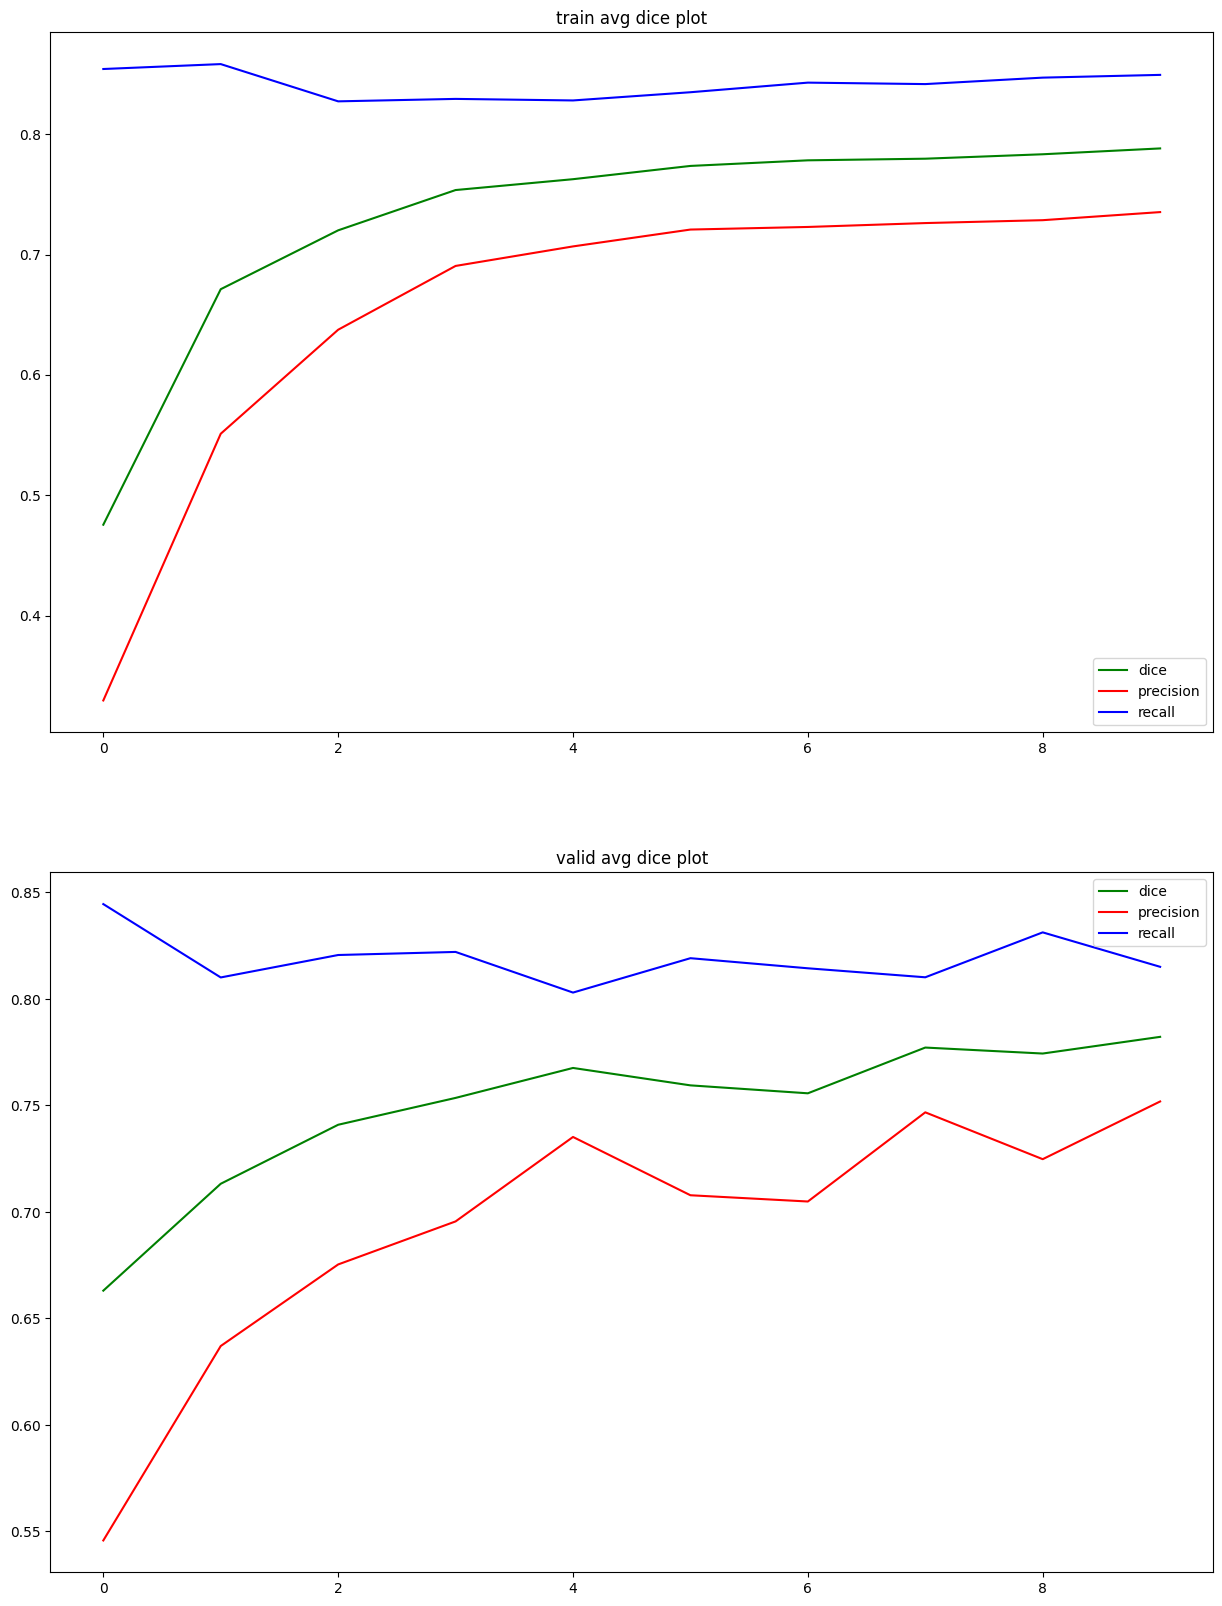

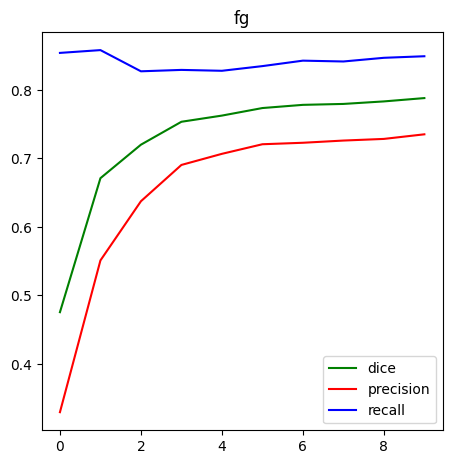

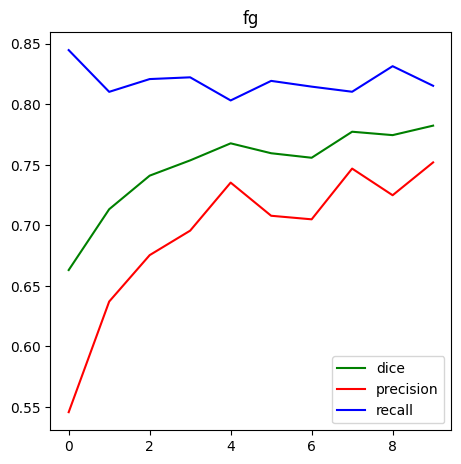

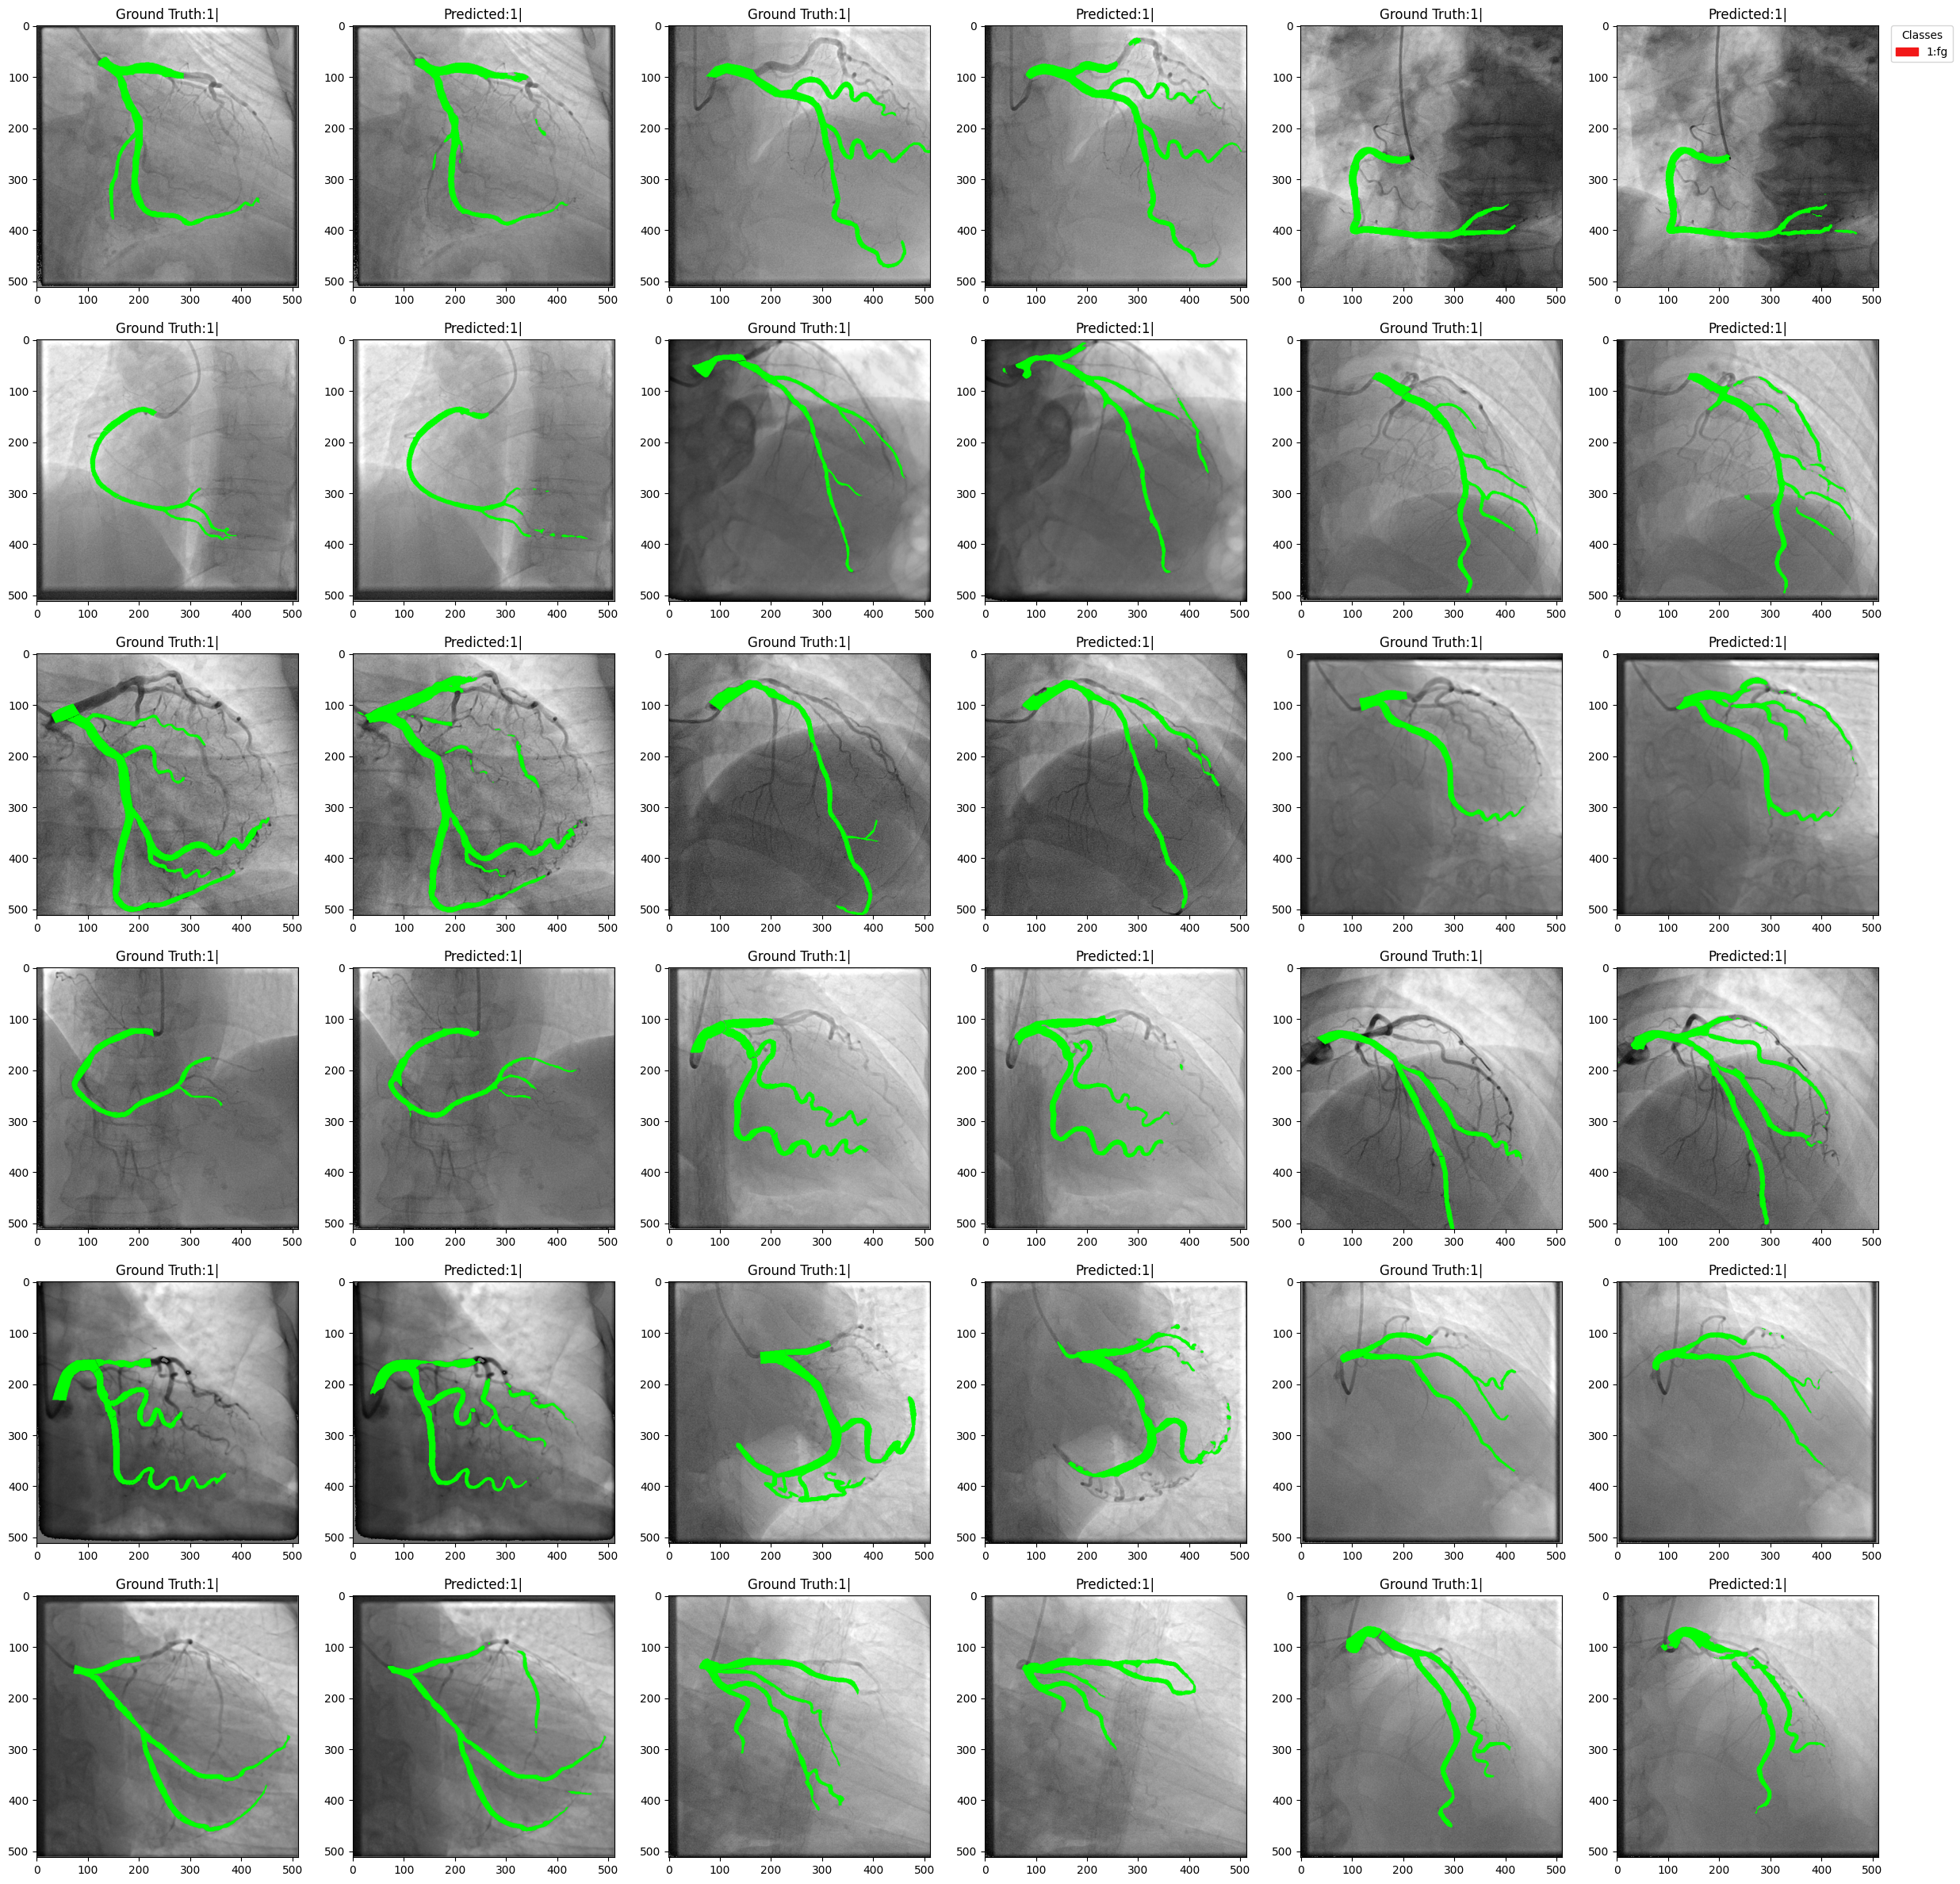

In [12]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
    just_binary_trining = args["just_binary_trining"],
    use_amp = args["use_amp"],
    binary_type = args["binary_type"]
)